/home/tkmcg/neuron-env/lib/python3.12/site-packages/pyNN/neuron/__init__.py:14: UserWarning: mpi4py not available
  warnings.warn("mpi4py not available")


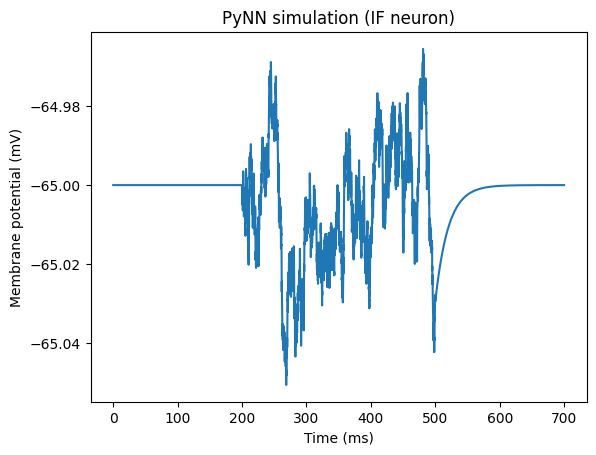

In [1]:
##### start with a Very simple neuron model - just one neuron #########
import pyNN.neuron as sim
import matplotlib.pyplot as plt

# Setup the simulation
sim.setup(timestep=0.1)

# Create a single neuron with passive properties
cell = sim.create(sim.IF_curr_exp, {
    'cm': 0.25,        # nF
    'tau_m': 20.0,     # ms
    'v_rest': -65.0,   # mV
    'v_reset': -65.0,  # mV
    'v_thresh': -50.0, # mV
    'tau_refrac': 5.0  # ms
})


#current source from the fleming simulation
stim = sim.NoisyCurrentSource(
    mean=0,
    stdev=0.005,
    start=200,
    stop=500,
    dt=0.1
)

stim.inject_into(cell)

'''# Inject a current pulse
stim = sim.DCSource(amplitude=0.5, start=20.0, stop=80.0)
stim.inject_into(cell)'''

# Record membrane potential
cell.record('v')

# Run the simulation
sim.run(700.0)

# Get and plot data
data = cell.get_data().segments[0]
vm = data.filter(name="v")[0]

plt.plot(vm.times, vm)
plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential (mV)")
plt.title("PyNN simulation (IF neuron)")
plt.show()


# Clean up
sim.end()

/home/tkmcg/neuron-env/lib/python3.12/site-packages/pyNN/neuron/__init__.py:14: UserWarning: mpi4py not available
  warnings.warn("mpi4py not available")


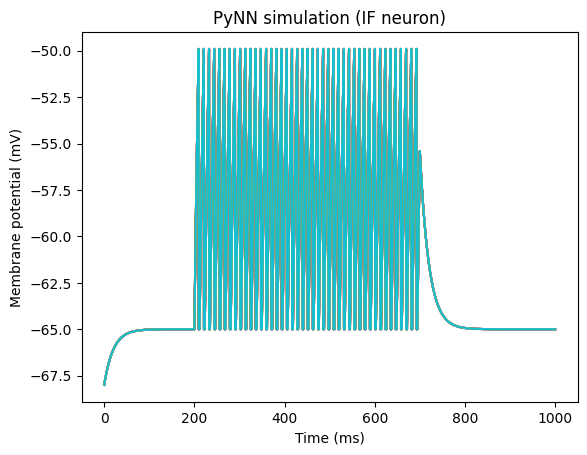

In [1]:
##### test different current sources #########
import pyNN.neuron as sim
import matplotlib.pyplot as plt
from pyNN.random import RandomDistribution

v_init = -68

# Setup the simulation
sim.setup(timestep=0.1)

cortical_type = sim.IF_curr_exp(
    tau_m=20.0,      # membrane time constant
    v_rest=-65.0,    # resting potential
    v_reset=-65.0,   # reset potential after spike
    v_thresh=-50.0,  # threshold
    cm=0.25,         # membrane capacitance
    tau_refrac=2.0   # refractory period
)

cell = sim.Population(10, cortical_type, initial_values={'v': v_init}, label="Cortical neurons")

'''#current source from the fleming simulation
stim = sim.NoisyCurrentSource(
    mean=0,
    stdev=0.005,
    start=200,
    stop=500,
    dt=0.1
)

stim.inject_into(cell)'''

# Inject a current pulse
stim = sim.DCSource(amplitude=0.5, start=200.0, stop=700.0)
stim.inject_into(cell)

# Record membrane potential
cell.record('v')

# Run the simulation
sim.run(1000.0)

# Get and plot data
data = cell.get_data().segments[0]
vm = data.filter(name="v")[0]

plt.plot(vm.times, vm)
plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential (mV)")
plt.title("PyNN simulation (IF neuron)")
plt.show()


# Clean up
sim.end()

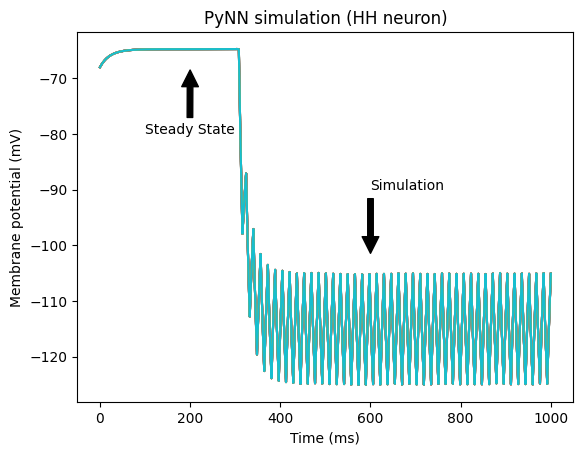

In [15]:
##### Building up to the model we have using HH neurons and the currents in the model ####
import pyNN.neuron as sim
import matplotlib.pyplot as plt
from pyNN import space
from pyNN.random import RandomDistribution, NumpyRNG
import numpy as np

fig, ax = plt.subplots()

v_init = -68
rng_seed = 856

# Setup the simulation
sim.setup(timestep=0.01)

STN_space = space.RandomStructure(boundary=space.Sphere(2000), rng=NumpyRNG(seed=rng_seed))

cortical_type = sim.HH_cond_exp()

cortical_pop = sim.Population(100, cortical_type, structure=STN_space, initial_values={'v': v_init}, label="Cortical neurons")


start = 300
stop = 1000

#current sources from the fleming simulation######
cortical_pop.inject(sim.DCSource(start=start, stop=stop, amplitude=0))

stim = sim.NoisyCurrentSource(
    mean=0,
    stdev=0.005,
    start=start,
    stop=stop,
    dt=1.0
)


for cell in cortical_pop:
    cell.inject(stim)

modulation_s = [0,-1,0,-1,0,-1,0,-1,0,-1,0,-1,0,-1,0,-1,0,-1,0,-1,0,-1,0,-1,0,-1,0,-1,0,-1,0,-1,0,-1,0,-1,0,-1,0,-1,0,-1,0,-1,0,-1,0,-1,0,-1,0,-1,0,-1,0,-1,0,-1,0,-1,0,-1,0,-1,0,-1,0,-1,0,-1,0,-1,0,-1,0,-1,0,-1,0,-1,0,-1,0,-1,0,-1,0,-1
]
modulation_t = np.linspace(start,stop,len(modulation_s))
cortical_modulation_current = sim.StepCurrentSource(times=modulation_t, amplitudes=modulation_s)
cortical_pop.inject(cortical_modulation_current)
#####################################################
#check the position of the cortical neurons
for Cortical_cell in cortical_pop:
        while (
            (np.abs(Cortical_cell.position[0]) > 2000)
            or ((np.abs(Cortical_cell.position[1]) > 2000))
        ) or (
            (np.abs(Cortical_cell.position[0]) < 500)
            and (-1500 < Cortical_cell.position[1] < 2000)
        ):
            Cortical_cell.position = STN_space.generate_positions(1).flatten()

####################################################
# Record membrane potential
#cortical_pop.record('v')

cortical_pop.sample(10).record('v')

# Run the simulation
sim.run(1000)

# Get and plot data
data = cortical_pop.get_data().segments[0]
vm = data.filter(name="v")[0]

plt.plot(vm.times, vm)
plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential (mV)")
plt.title("PyNN simulation (HH neuron)")
ax.annotate('Steady State', xy=(200, -68), xytext=(100, -80),arrowprops=dict(facecolor='black', shrink=0.05))
ax.annotate('Simulation', xy=(600, -102), xytext=(600, -90),arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()


# Clean up
sim.end()

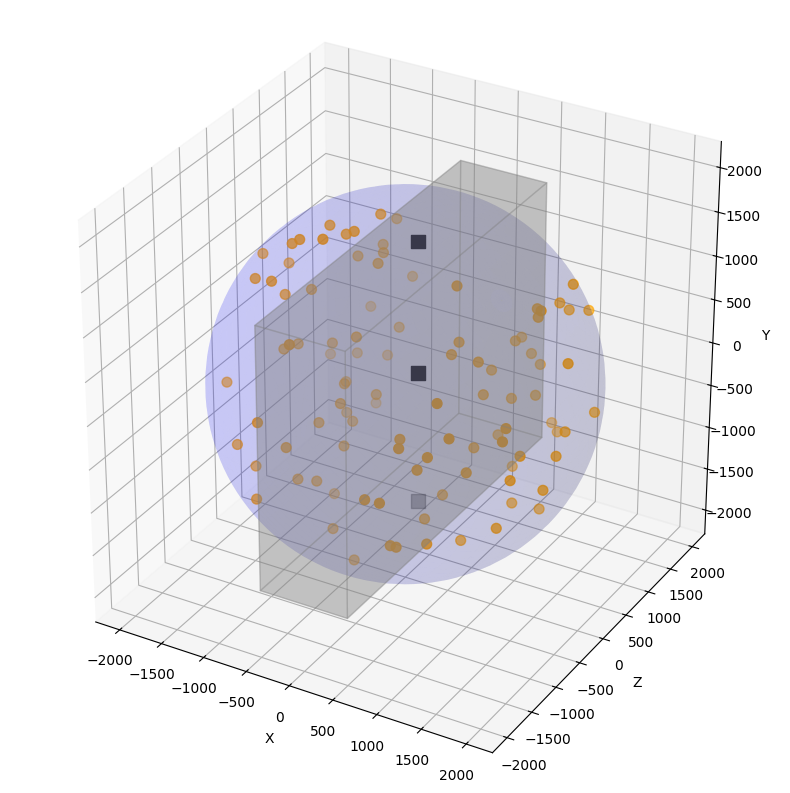

In [5]:
###### plot where the cortical neurons are in the STn space #########
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
#%matplotlib widget


#plot sphere of STN
theta = np.linspace(0, 2 * np.pi, 100)
phi = np.linspace(0, np.pi, 50)
theta, phi = np.meshgrid(theta, phi)
r = 2000

# Convert to Cartesian coordinates
x = r * np.sin(phi) * np.cos(theta)
y = r * np.sin(phi) * np.sin(theta)
z = r * np.cos(phi)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, z, y, color = "blue",alpha=0.1)
ax.set_xlabel('X')
ax.set_ylabel('Z')
ax.set_zlabel('Y')
ax.set_box_aspect((1, 1, 1))

#plot the stimulating electrode remeber y <-> z
ax.scatter(0, 250, 0, c='black', s=100, marker = "s")
#plot the receiving electrode
ax.scatter([0,0], [250,250], [-1500,1500], c='black', s=100, marker = "s")


#plot the no-go space
cube_vertices = np.array([
    [-500, -2000, -1500],  # point 0
    [ 500, -2000, -1500],  # point 1
    [ 500,  2000, -1500],  # point 2
    [-500,  2000, -1500],  # point 3
    [-500, -2000,  1500],  # point 4
    [ 500, -2000,  1500],  # point 5
    [ 500,  2000,  1500],  # point 6
    [-500,  2000,  1500],  # point 7
])

# Define cube faces using the vertices
faces = [
    [cube_vertices[i] for i in [0, 1, 2, 3]],  # bottom
    [cube_vertices[i] for i in [4, 5, 6, 7]],  # top
    [cube_vertices[i] for i in [0, 1, 5, 4]],  # front
    [cube_vertices[i] for i in [2, 3, 7, 6]],  # back
    [cube_vertices[i] for i in [1, 2, 6, 5]],  # right
    [cube_vertices[i] for i in [0, 3, 7, 4]]   # left
]
ax.add_collection3d(Poly3DCollection(faces, facecolors='gray', alpha=0.25, linewidths=1, edgecolor = 'gray', label = "No-Go Zone"))

##### add in the cortical neurons

x_points_clean_ctx = cortical_pop.positions[0]
y_points_clean_ctx = cortical_pop.positions[1]
z_points_clean_ctx = cortical_pop.positions[2]

ax.scatter(x_points_clean_ctx, z_points_clean_ctx, y_points_clean_ctx, c='orange', s=50)

plt.show()

<ParameterSpace amplitude, start, stop, shape=None>
